# Illustration 7.7-1 and Figure 7.7-1 &mdash; the Clausius&ndash;Clapeyron equation

**Illustration 7.7-1** (*Use of the Clausius&ndash;Clapeyron Equation*) runs the other way
from everything else in this chapter. Sections 7.4 and 7.5 started from an equation of
state and *predicted* a vapor pressure. Here we start from nine measured vapor pressures
of liquid 2,2,4-trimethyl pentane (isooctane) and work backwards to a quantity nobody
measured directly: the enthalpy of vaporization $\Delta_{\mathrm{vap}}\underline H$ at
$25\,^\circ$C.

That inversion is the point. As the text puts it, this is *"a nice example of the utility
of thermodynamics in providing interrelationships between properties"* &mdash; the
Clapeyron equation ties the slope of the coexistence curve to $\Delta_{\mathrm{vap}}
\underline H$, so measuring one gives you the other.

This notebook produces both parts of the illustration &mdash; the two-point estimate and
**Figure 7.7-1** &mdash; and then does the thing the printed page cannot: it *checks the
conclusion the illustration draws from that figure*. The text reads the plot's straightness
as evidence that $\Delta_{\mathrm{vap}}\underline H$ is "virtually constant over the whole
temperature range." A logarithmic plot spanning two and a half decades turns out to be a
very weak test of that, and the same nine numbers say something more interesting.

SIS is Stanley I. Sandler, *Chemical, Biochemical, and Engineering Thermodynamics*.

Eric Furst
August 2026

In [ ]:
# --- Colab bootstrap -------------------------------------------------------
# This notebook labels its axes with the book's molar underbar, $\underline{V}$.
# With no LaTeX installed, matplotlib renders math with its own "mathtext"
# engine, which only learned \underline in version 3.11 -- and Colab still
# ships 3.10. Upgrade there; with a current matplotlib this does nothing.
import sys
from importlib.metadata import version

if tuple(map(int, version("matplotlib").split(".")[:2])) < (3, 11):
    !pip install -q "matplotlib>=3.11"
    if "matplotlib" in sys.modules:
        print("matplotlib upgraded - Runtime > Restart session, then Run all.")
# ---------------------------------------------------------------------------

In [1]:
# --- Colab bootstrap -------------------------------------------------------
# No-op when you already have the thermo package alongside this notebook (the
# normal case: you cloned the repository and are running from code/chNN/).
# In Colab there is no repository, so fetch the package and the property data.
import os, sys
if not (os.path.isdir('../thermo') or os.path.isdir('thermo')):
    !git clone -q --depth 1 https://github.com/emfurst/cbet6e.git /tmp/cbet6e
    !cp -r /tmp/cbet6e/code/thermo /tmp/cbet6e/code/data .
    sys.path.insert(0, '.')
# ---------------------------------------------------------------------------

## The data

Nine vapor pressures, from $-15.0$ to $99.2\,^\circ$C, spanning 0.667 to 101.32 kPa.

Look at the pressures before anything else. They are not round numbers in kPa &mdash; but
they are exactly 5, 10, 20, 40, 60, 100, 200, 400, and 760 **mmHg**. This is a classical
boiling-point table: the experimenter *set* the pressure to a round value in torr and
*measured* the temperature at which the liquid boiled. That has a practical consequence
worth carrying through the rest of the notebook &mdash; the experimental uncertainty lives
in the temperatures, not the pressures, so when we look at how far the data fall from a
straight line, the honest way to express that distance is in kelvin.

In [2]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import constants
from scipy.optimize import least_squares

# Typography, matching the other recomputed figures: use a real LaTeX installation when
# there is one, so the figure is set in Computer Modern like the book, and fall back to
# matplotlib's own mathtext otherwise — the notebook still runs in Colab, which has no
# TeX. The fallback keeps a serif face and CM math.
from shutil import which

mpl.rcParams["text.usetex"] = which("latex") is not None
mpl.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",   # Computer Modern math for the no-TeX fallback
    "pdf.fonttype": 42,         # keep text as text in the PDF
    "ps.fonttype": 42,
})

R = constants.R          # gas constant, J/(mol K)
TO_KELVIN = 273.15
MMHG = 133.3224          # Pa per mmHg (torr)

# Illustration 7.7-1: vapor pressure of liquid 2,2,4-trimethyl pentane
data = pd.DataFrame({
    "P_kPa": [0.667, 1.333, 2.666, 5.333, 8.000, 13.33, 26.66, 53.33, 101.32],
    "t_C":   [-15.0,  -4.3,   7.5,  20.7,  29.1,  40.7,  58.1,  78.0,   99.2],
})
data["T"] = data["t_C"] + TO_KELVIN
data["invT"] = 1.0 / data["T"]
data["mmHg"] = data["P_kPa"] * 1e3 / MMHG

print(data[["t_C", "T", "P_kPa", "mmHg"]].to_string(index=False, formatters={
    "t_C": "{:.1f}".format, "T": "{:.2f}".format,
    "P_kPa": "{:.3f}".format, "mmHg": "{:.1f}".format}))

print(f"\nthe pressures are round numbers in mmHg to within "
      f"{np.abs(data['mmHg'] - data['mmHg'].round()).max():.3f} torr")
print(f"the last point, {data['P_kPa'].iloc[-1]} kPa at {data['t_C'].iloc[-1]} C, is "
      f"1 atm ({constants.atm/1e3:.3f} kPa) —\nso it is the normal boiling point")

  t_C      T   P_kPa  mmHg
-15.0 258.15   0.667   5.0
 -4.3 268.85   1.333  10.0
  7.5 280.65   2.666  20.0
 20.7 293.85   5.333  40.0
 29.1 302.25   8.000  60.0
 40.7 313.85  13.330 100.0
 58.1 331.25  26.660 200.0
 78.0 351.15  53.330 400.0
 99.2 372.35 101.320 760.0

the pressures are round numbers in mmHg to within 0.038 torr
the last point, 101.32 kPa at 99.2 C, is 1 atm (101.325 kPa) —
so it is the normal boiling point


## From Clapeyron to Clausius&ndash;Clapeyron

The exact result is the **Clapeyron equation**, which follows from nothing more than
$\underline G^{\mathrm{I}} = \underline G^{\mathrm{II}}$ holding all along the coexistence
curve:

$$ \left(\frac{\partial P^{\mathrm{sat}}}{\partial T}\right)_{\underline G^{\mathrm{I}}
   = \underline G^{\mathrm{II}}}
   = \frac{\Delta \underline S}{\Delta \underline V}
   = \frac{\Delta \underline H}{T\,\Delta \underline V} \tag{Eq. 7.7-4}$$

It is exact for *any* phase transition. To get from it to something you can use on a table
of vapor pressures, the text makes **two approximations**. State them explicitly, because they
come back at the end of this notebook:

1. the vapor is far more expansive than the liquid, $\underline V^{V} \gg \underline V^{L}$,
   so $\Delta_{\mathrm{vap}}\underline V \approx \underline V^{V}$; and
2. the vapor is an ideal gas, $\underline V^{V} = RT/P$.

Together these give the **Clausius&ndash;Clapeyron equation**

$$ \frac{dP^{\mathrm{vap}}}{dT} = \frac{P^{\mathrm{vap}}\,
   \Delta_{\mathrm{vap}}\underline H}{RT^{2}}
   \qquad\text{or}\qquad
   \frac{d\ln P^{\mathrm{vap}}}{dT} = \frac{\Delta_{\mathrm{vap}}\underline H}{RT^{2}}
   \tag{Eq. 7.7-5a}$$

and if $\Delta_{\mathrm{vap}}\underline H$ is taken constant, integrating between two
states gives the form the illustration uses:

$$ \ln\frac{P^{\mathrm{vap}}(T_2)}{P^{\mathrm{vap}}(T_1)}
   = -\frac{\Delta_{\mathrm{vap}}\underline H}{R}
     \left(\frac{1}{T_2} - \frac{1}{T_1}\right) \tag{Eq. 7.7-6}$$

Equivalently, as an indefinite integral,
$\ln P^{\mathrm{vap}}(T) = -\Delta_{\mathrm{vap}}\underline H/(RT) + C$: **$\ln P$ linear
in $1/T$, with slope $-\Delta_{\mathrm{vap}}\underline H/R$.** That is the whole basis of
Figure 7.7-1, and of everything below.

### The illustration's estimate

To get $\Delta_{\mathrm{vap}}\underline H$ *at $25\,^\circ$C* the illustration picks the
two tabulated temperatures that straddle it &mdash; 20.7 and $29.1\,^\circ$C &mdash; and
applies Eq. 7.7-6 to that pair alone. The interval is only 8.4 K wide, which is the point:
over a short enough span, assuming $\Delta_{\mathrm{vap}}\underline H$ constant costs
almost nothing.

In [3]:
def two_point(i1, i2):
    """Delta_vap H (J/mol) from Eq. 7.7-6 applied to two tabulated points."""
    T1, T2 = data["T"].iloc[i1], data["T"].iloc[i2]
    P1, P2 = data["P_kPa"].iloc[i1], data["P_kPa"].iloc[i2]
    return -R * np.log(P2 / P1) / (1 / T2 - 1 / T1)


I1, I2 = 3, 4                                  # 20.7 C and 29.1 C, straddling 25 C
dH_25 = two_point(I1, I2)

print(f"T1 = {data['T'].iloc[I1]:.2f} K ({data['t_C'].iloc[I1]} C), "
      f"P1 = {data['P_kPa'].iloc[I1]} kPa")
print(f"T2 = {data['T'].iloc[I2]:.2f} K ({data['t_C'].iloc[I2]} C), "
      f"P2 = {data['P_kPa'].iloc[I2]} kPa\n")
print(f"Delta_vap H / R = {dH_25 / R:.1f} K")
print(f"Delta_vap H     = {dH_25 / 1000:.3f} kJ/mol   at 25 C")

T1 = 293.85 K (20.7 C), P1 = 5.333 kPa
T2 = 302.25 K (29.1 C), P2 = 8.0 kPa

Delta_vap H / R = 4287.8 K
Delta_vap H     = 35.651 kJ/mol   at 25 C


## Figure 7.7-1

The axes are chosen to make Eq. 7.7-6 legible:

- the abscissa is $(1/T)\times 10^{3}$ in K$^{-1}$, so a constant
  $\Delta_{\mathrm{vap}}\underline H$ plots as a straight line. Temperature therefore
  increases to the **left**, which takes a moment to get used to and is worth the
  straight line;
- the ordinate is $P^{\mathrm{vap}}$ on a **logarithmic** scale, which is the same thing
  as plotting $\ln P^{\mathrm{vap}}$ linearly but leaves the numbers readable in the units
  the data were measured in. It is labeled at 0.5, 1, 2, 5, 10, 20, 50, 100 kPa rather
  than at decades, so that all nine measurements can be read off;
- a second abscissa across the top carries $T$ itself in kelvin, because $1/T$ is not a
  quantity anyone has intuition for.

Between them these axes are exactly the $\ln P$-versus-$1/T$ plot the Clausius&ndash;Clapeyron
equation calls for. The curve is drawn through the nine points.

A high-resolution PDF is written to `pdf/Fig_7.7-1.pdf`.

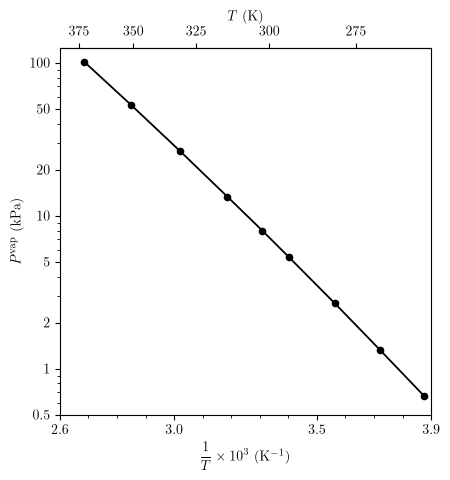

In [4]:
import os
from matplotlib.ticker import FixedLocator, MultipleLocator, NullFormatter

INV_LO, INV_HI = 2.6, 3.9            # (1/T) x 10^3, bracketing the nine measurements
BLACK = "black"

fig, ax = plt.subplots(figsize=(4.6, 4.9))

x = 1e3 * data["invT"]
ax.plot(x, data["P_kPa"], "-o", color=BLACK, lw=1.3, ms=4.5, mfc=BLACK, mec=BLACK)

ax.set_yscale("log")
ax.set_xlim(INV_LO, INV_HI)
# The top of the frame sits a little above the 100 kPa tick so the last point, which is
# 1 atm = 101.32 kPa, falls inside the axes.
ax.set_ylim(0.5, 125)

# Label the ordinate at readable pressures rather than at decades, so every measurement
# can be read off the axis.
P_TICKS = [0.5, 1, 2, 5, 10, 20, 50, 100]
ax.yaxis.set_major_locator(FixedLocator(P_TICKS))
ax.set_yticklabels([f"{p:g}" for p in P_TICKS])
ax.yaxis.set_minor_formatter(NullFormatter())

ax.xaxis.set_major_locator(FixedLocator([2.6, 3.0, 3.5, 3.9]))
ax.xaxis.set_minor_locator(MultipleLocator(0.1))

# Set 1/T as a large stacked fraction. \displaystyle does that under LaTeX; matplotlib's
# mathtext has no \displaystyle, but its plain \frac is already large. Units upright.
FRAC = r"\displaystyle\frac" if mpl.rcParams["text.usetex"] else r"\frac"
ax.set_xlabel(rf"${FRAC}{{1}}{{T}} \times 10^{{3}}$  (K$^{{-1}}$)")
ax.set_ylabel(r"$P^{\mathrm{vap}}$  (kPa)")

# --- second abscissa: temperature itself, at (1/T) x 10^3 positions ---
top = ax.secondary_xaxis("top", functions=(lambda v: v, lambda v: v))
T_TICKS = [375, 350, 325, 300, 275]
top.xaxis.set_major_locator(FixedLocator([1e3 / T for T in T_TICKS]))
top.set_xticklabels([f"{T}" for T in T_TICKS])
top.set_xlabel(r"$T$  (K)")

os.makedirs("pdf", exist_ok=True)
fig.tight_layout()
fig.savefig("pdf/Fig_7.7-1.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Is $\Delta_{\mathrm{vap}}\underline H$ really constant?

Here is the claim the illustration makes from that figure:

> Therefore, if we were to plot $\ln P^{\mathrm{vap}}$ versus $1/T$, we should get a
> straight line with a slope equal to $-\Delta_{\mathrm{vap}}\underline H/R$ if the heat
> of vaporization is independent of temperature, and a curve if
> $\Delta_{\mathrm{vap}}\underline H$ varies with temperature. &hellip; As is evident from
> the linearity of the plot, $\Delta_{\mathrm{vap}}\underline H$ is virtually constant over
> the whole temperature range.

The reasoning is exactly right. The *test* is the weak part, and this is worth dwelling on
because the same trap is everywhere in engineering practice: **a log plot spanning decades
is very forgiving of slope changes.** Across this figure $P^{\mathrm{vap}}$ changes by a
factor of 152. A slope that drifts by ten percent over that range moves the points a few
percent off a straight line &mdash; less than the width of the plotted symbols. The eye
cannot see it. Least squares can.

So: fit the straight line Eq. 7.7-6 predicts, and look at what is left over.

In [5]:
slope, intercept = np.polyfit(data["invT"], np.log(data["P_kPa"]), 1)
dH_fit = -slope * R
resid = np.log(data["P_kPa"]) - (slope * data["invT"] + intercept)

# The measured quantity is T, not P (see the mmHg note at the top), so convert each
# residual into the temperature offset that would produce it:  d lnP/dT = -slope/T^2.
resid_K = resid / (-slope / data["T"]**2)

print(f"least squares over all 9 points:")
print(f"  slope     = {slope:.1f} K   ->  Delta_vap H = {dH_fit/1000:.3f} kJ/mol")
print(f"  intercept = {intercept:.4f}\n")
print(f"  vs the two-point estimate at 25 C: {dH_25/1000:.3f} kJ/mol "
      f"({100*(dH_fit-dH_25)/dH_25:+.1f}%)\n")

out = pd.DataFrame({
    "t (C)": data["t_C"], "P (kPa)": data["P_kPa"],
    "resid in lnP": resid, "% in P": 100 * (np.exp(resid) - 1), "equiv. dT (K)": resid_K})
print(out.to_string(index=False, formatters={
    "t (C)": "{:.1f}".format, "P (kPa)": "{:.3f}".format,
    "resid in lnP": "{:+.4f}".format, "% in P": "{:+.2f}".format,
    "equiv. dT (K)": "{:+.2f}".format}))

print(f"\nlargest deviation: {100*np.abs(np.exp(resid)-1).max():.1f}% in pressure, "
      f"{np.abs(resid_K).max():.2f} K in temperature")
print(f"the temperatures are quoted to 0.1 C — the deviation is "
      f"{np.abs(resid_K).max()/0.1:.0f}x larger than that")

least squares over all 9 points:
  slope     = -4227.5 K   ->  Delta_vap H = 35.149 kJ/mol
  intercept = 16.0273

  vs the two-point estimate at 25 C: 35.651 kJ/mol (-1.4%)

t (C) P (kPa) resid in lnP % in P equiv. dT (K)
-15.0   0.667      -0.0562  -5.46         -0.89
 -4.3   1.333      -0.0155  -1.54         -0.27
  7.5   2.666      +0.0165  +1.66         +0.31
 20.7   5.333      +0.0332  +3.37         +0.68
 29.1   8.000      +0.0389  +3.96         +0.84
 40.7  13.330      +0.0325  +3.30         +0.76
 58.1  26.660      +0.0181  +1.82         +0.47
 78.0  53.330      -0.0118  -1.18         -0.35
 99.2 101.320      -0.0555  -5.40         -1.82

largest deviation: 5.5% in pressure, 1.82 K in temperature
the temperatures are quoted to 0.1 C — the deviation is 18x larger than that


### The residuals are a curve, not scatter

Read the sign column: $-\,-\,+\,+\,+\,+\,+\,-\,-$. The residuals go negative at both ends
and positive through the middle, in one smooth arc &mdash; the signature of fitting a
straight line to something gently bent. Random measurement error does not do that; it
changes sign unpredictably.

And the size settles the question. The worst deviation is 1.8 K, in data whose
temperatures are quoted to $0.1\,^\circ$C. Whatever is bending this line, it is nearly
twenty times too large to be experimental scatter in the temperature measurement.

So the plot really is a curve. The most direct way to see what that curvature means is to
stop fitting one line to everything and instead apply Eq. 7.7-6 to each *adjacent pair* of
points, exactly as the illustration did for the pair straddling $25\,^\circ$C. Each pair
spans 8&ndash;21 K, over which taking $\Delta_{\mathrm{vap}}\underline H$ constant is
perfectly reasonable &mdash; so each gives a local value, at the midpoint temperature.

In [6]:
local = pd.DataFrame([{
    "T mid (K)": (data["T"].iloc[i] + data["T"].iloc[i + 1]) / 2,
    "t mid (C)": (data["T"].iloc[i] + data["T"].iloc[i + 1]) / 2 - TO_KELVIN,
    "span (K)": data["T"].iloc[i + 1] - data["T"].iloc[i],
    "dH (kJ/mol)": two_point(i, i + 1) / 1000,
} for i in range(len(data) - 1)])

print(local.to_string(index=False, formatters={
    "T mid (K)": "{:.1f}".format, "t mid (C)": "{:+.1f}".format,
    "span (K)": "{:.1f}".format, "dH (kJ/mol)": "{:.3f}".format}))

lo, hi = local["dH (kJ/mol)"].min(), local["dH (kJ/mol)"].max()
print(f"\nDelta_vap H falls monotonically from {hi:.2f} to {lo:.2f} kJ/mol "
      f"— a {100*(hi-lo)/hi:.1f}% decrease")
print(f"the single straight-line fit, {dH_fit/1000:.3f} kJ/mol, is a range-average of "
      f"these\nand describes no particular temperature")

T mid (K) t mid (C) span (K) dH (kJ/mol)
    263.5      -9.6     10.7      37.341
    274.8      +1.6     11.8      36.851
    287.2     +14.1     13.2      36.016
    298.0     +24.9      8.4      35.651
    308.0     +34.9     11.6      34.716
    322.5     +49.4     17.4      34.434
    341.2     +68.1     19.9      33.696
    361.8     +88.6     21.2      32.910

Delta_vap H falls monotonically from 37.34 to 32.91 kJ/mol — a 11.9% decrease
the single straight-line fit, 35.149 kJ/mol, is a range-average of these
and describes no particular temperature


That is not "virtually constant." $\Delta_{\mathrm{vap}}\underline H$ decreases steadily
and by about an eighth across the range, and it does so for a reason the chapter has
already given: $\Delta_{\mathrm{vap}}\underline H$ must vanish at the critical point
(Sec. 7.3, and the discussion following Eq. 7.7-4). Isooctane's $T_c$ is 544 K, so the
top of this table, 372 K, is already at $T_r = 0.68$ and heading downhill.

Notice also what this does to the two estimates in hand. The two-point value, 35.65
kJ/mol, is a *local* result at $25\,^\circ$C and is the right answer to the question the
illustration asked. The straight-line fit over all nine points, 35.15 kJ/mol, is a
weighted average over $-15$ to $99\,^\circ$C; it looks like a better answer because it uses
all the data, and it is a worse one, because it answers a different question.

## A better correlating equation: Antoine

The text turns to this immediately after the illustration. Rewriting the indefinite
integral as

$$ \ln P^{\mathrm{vap}}(T) = A - \frac{B}{T}, \qquad B = \frac{\Delta_{\mathrm{vap}}
   \underline H}{R} \tag{Eq. 7.7-7}$$

makes the two-parameter form's limitation explicit: with $B$ constant it *cannot* bend. The
**Antoine equation** adds a single constant to the denominator,

$$ \ln P^{\mathrm{vap}}(T) = A - \frac{B}{T + C} \tag{Eq. 7.7-8}$$

and the book says it "is used to correlate vapor pressures accurately over the range from
1 to 200 kPa" &mdash; which is this range. One extra parameter is enough to carry the
curvature, and differentiating it gives $\Delta_{\mathrm{vap}}\underline H$ as a function
of temperature rather than a single number:

$$ \frac{d \ln P^{\mathrm{vap}}}{d(1/T)} = -\frac{\Delta_{\mathrm{vap}}\underline H}{R}
   \qquad\Longrightarrow\qquad
   \Delta_{\mathrm{vap}}\underline H(T) = \frac{R\,B\,T^{2}}{(T+C)^{2}} $$

Fitting three constants to nine points is a nonlinear least-squares problem, so
`scipy.optimize.least_squares` does the work.

In [7]:
def ln_antoine(p, T):
    A, B, C_ = p
    return A - B / (T + C_)


fit = least_squares(lambda p: ln_antoine(p, data["T"].to_numpy())
                    - np.log(data["P_kPa"].to_numpy()),
                    x0=[14.0, 3000.0, -50.0])
A, B, C_ = fit.x

resid_ant = np.log(data["P_kPa"]) - ln_antoine(fit.x, data["T"])
print(f"Antoine (P in kPa, T in K):  ln P = {A:.5f} - {B:.3f} / (T {C_:+.3f})\n")
print(f"{'fit':<22}{'max error in P':>16}")
print(f"{'straight line (7.7-7)':<22}{100*np.abs(np.exp(resid)-1).max():15.2f}%")
print(f"{'Antoine (7.7-8)':<22}{100*np.abs(np.exp(resid_ant)-1).max():15.2f}%")
print(f"\none extra constant improves the fit by a factor of "
      f"{np.abs(resid).max()/np.abs(resid_ant).max():.0f}")


def dH_antoine(T):
    """Delta_vap H (J/mol) from the fitted Antoine constants."""
    return R * B * T**2 / (T + C_)**2


print(f"\nDelta_vap H from the Antoine fit:")
for t in (-15.0, 25.0, 99.2):
    print(f"  {t:6.1f} C   {dH_antoine(t + TO_KELVIN)/1000:.3f} kJ/mol")
print(f"\nat 25 C: {dH_antoine(298.15)/1000:.3f} kJ/mol, against the illustration's "
      f"{dH_25/1000:.3f} kJ/mol")

Antoine (P in kPa, T in K):  ln P = 13.70279 - 2912.858 / (T -51.693)

fit                     max error in P
straight line (7.7-7)            5.46%
Antoine (7.7-8)                  0.22%

one extra constant improves the fit by a factor of 26

Delta_vap H from the Antoine fit:
   -15.0 C   37.865 kJ/mol
    25.0 C   35.444 kJ/mol
    99.2 C   32.657 kJ/mol

at 25 C: 35.444 kJ/mol, against the illustration's 35.651 kJ/mol


## An independent check, and what the two approximations cost

Everything so far came out of these nine numbers. Two independent sources are available in
the repository, and both use the book's own property database
(`code/data/pure_property.csv`, the digitized Appendix A):

1. **A Wagner vapor-pressure correlation** for 2,2,4-trimethyl pentane, fitted to a much
   larger body of data than the nine points here, over 265&ndash;544 K.
2. **The Peng&ndash;Robinson equation of state**, from the same row's $T_c$, $P_c$, and
   $\omega$ &mdash; which lets us finally price the two approximations that took us from
   the exact Clapeyron equation to Clausius&ndash;Clapeyron.

That second one matters more than it looks. Going back to Eq. 7.7-4 without approximating,

$$ \frac{d \ln P^{\mathrm{vap}}}{d(1/T)}
   = -\frac{\Delta_{\mathrm{vap}}\underline H}{R\,\Delta Z},
   \qquad \Delta Z = Z^{V} - Z^{L} $$

Clausius&ndash;Clapeyron is the statement $\Delta Z = 1$ &mdash; an ideal vapor
($Z^{V} = 1$) and a liquid of negligible volume ($Z^{L} = 0$). So every
$\Delta_{\mathrm{vap}}\underline H$ obtained from a slope above is really
$\Delta_{\mathrm{vap}}\underline H/\Delta Z$, and multiplying by $\Delta Z$ recovers the
true value.

In [8]:
import sys
sys.path.insert(0, "..")            # so `thermo` resolves when run from code/ch7/
from thermo import PengRobinson

pr = PengRobinson.from_database("2,2,4-trimethylpentane")
print(f"2,2,4-trimethyl pentane: Tc = {pr.Tc} K, Pc = {pr.Pc/1e5:.1f} bar, "
      f"omega = {pr.omega}")
print(f"the data run to Tr = {data['T'].max()/pr.Tc:.2f}\n")

# --- 1. the database Wagner correlation, ln(P/Pc) = (a t + b t^1.5 + c t^3 + d t^6)/(1-t)
from thermo.data import get_compound

row = get_compound("2,2,4-trimethylpentane")
wa, wb, wc, wd = row["VpA"], row["VpB"], row["VpC"], row["VpD"]


def P_wagner(T):
    """Vapor pressure (Pa) from the pure_property.csv Wagner constants (Eq = 1)."""
    t = 1 - np.asarray(T, dtype=float) / pr.Tc
    return pr.Pc * np.exp((wa * t + wb * t**1.5 + wc * t**3 + wd * t**6) / (1 - t))


err_w = 100 * (P_wagner(data["T"]) / (data["P_kPa"] * 1e3) - 1)
print(f"Wagner correlation vs the nine data points: max {np.abs(err_w).max():.2f}%, "
      f"mean |error| {np.abs(err_w).mean():.2f}%")


def dH_wagner(T, h=0.01):
    """Delta_vap H (J/mol) from the Wagner curve, via d lnP / d(1/T)."""
    return -R * (np.log(P_wagner(T + h)) - np.log(P_wagner(T - h))) \
        / (1 / (T + h) - 1 / (T - h))


# --- 2. Peng-Robinson: what Delta Z actually is along the saturation line
dZ = np.array([pr.Z(T, P) - pr.Z(T, P, phase="liquid")
               for T, P in zip(data["T"], data["P_kPa"] * 1e3)])

print(f"\n{'t (C)':>7}{'Zvap':>9}{'Zliq':>10}{'dZ':>9}{'CC error':>11}")
for (T, P), d in zip(zip(data["T"], data["P_kPa"] * 1e3), dZ):
    print(f"{T-TO_KELVIN:7.1f}{pr.Z(T, P):9.4f}{pr.Z(T, P, phase='liquid'):10.5f}"
          f"{d:9.4f}{100*(1-d):10.2f}%")

print(f"""
Reading this: neglecting the liquid volume and calling the vapor ideal is worth
{100*(1-dZ[0]):.2f}% at the cold end and {100*(1-dZ[-1]):.1f}% at the normal boiling point. The
approximations are excellent where the vapor pressure is low — which is exactly the
regime the text says they hold in — and they are quietly eroding by the top of
the table.""")

2,2,4-trimethyl pentane: Tc = 544.0 K, Pc = 25.7 bar, omega = 0.303
the data run to Tr = 0.68

Wagner correlation vs the nine data points: max 1.42%, mean |error| 0.46%

  t (C)     Zvap      Zliq       dZ   CC error
  -15.0   0.9992   0.00005   0.9992      0.08%
   -4.3   0.9986   0.00009   0.9985      0.15%
    7.5   0.9975   0.00018   0.9973      0.27%
   20.7   0.9955   0.00035   0.9951      0.49%
   29.1   0.9937   0.00051   0.9932      0.68%
   40.7   0.9904   0.00083   0.9896      1.04%
   58.1   0.9833   0.00161   0.9817      1.83%
   78.0   0.9712   0.00312   0.9680      3.20%
   99.2   0.9526   0.00578   0.9468      5.32%

Reading this: neglecting the liquid volume and calling the vapor ideal is worth
0.08% at the cold end and 5.3% at the normal boiling point. The
approximations are excellent where the vapor pressure is low — which is exactly the
regime the text says they hold in — and they are quietly eroding by the top of
the table.


### Putting it together

Four routes to $\Delta_{\mathrm{vap}}\underline H(T)$, three of them temperature-resolved:
the adjacent-pair differences, the Antoine fit, the database Wagner correlation, and the
same Wagner result corrected by $\Delta Z$ to remove the Clausius&ndash;Clapeyron
approximations. The single straight-line fit is drawn as a horizontal line, since that is
precisely what it assumes.

*This one is not a book figure* &mdash; Section 7.7 carries only Figure 7.7-1. It is a
diagnostic, so it gets no QR key and no PDF is written.

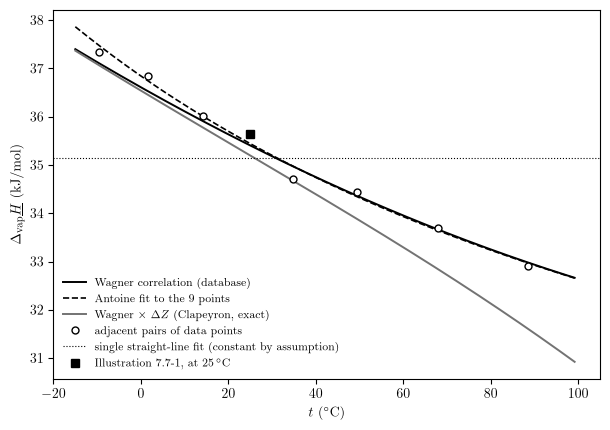

at the normal boiling point (99.2 C):
  Clausius-Clapeyron   32.66 kJ/mol
  Clapeyron (x dZ)     30.92 kJ/mol


In [9]:
T_grid = np.linspace(data["T"].min(), data["T"].max(), 200)
dZ_grid = np.array([pr.Z(T, P_wagner(T)) - pr.Z(T, P_wagner(T), phase="liquid")
                    for T in T_grid])

fig, ax = plt.subplots(figsize=(6.2, 4.4))

ax.plot(T_grid - TO_KELVIN, dH_wagner(T_grid) / 1000, "-", color="black", lw=1.4,
        label="Wagner correlation (database)")
ax.plot(T_grid - TO_KELVIN, dH_antoine(T_grid) / 1000, "--", color="black", lw=1.2,
        label="Antoine fit to the 9 points")
ax.plot(T_grid - TO_KELVIN, dH_wagner(T_grid) * dZ_grid / 1000, "-", color="0.45",
        lw=1.4, label=r"Wagner $\times\ \Delta Z$ (Clapeyron, exact)")
ax.plot(local["t mid (C)"], local["dH (kJ/mol)"], "o", mfc="white", mec="black",
        ms=5, mew=1.0, label="adjacent pairs of data points")
ax.axhline(dH_fit / 1000, color="black", lw=0.8, ls=":",
           label="single straight-line fit (constant by assumption)")
ax.plot([25.0], [dH_25 / 1000], "s", color="black", ms=6,
        label=r"Illustration 7.7-1, at $25\,^\circ$C")

ax.set_xlabel(r"$t$  ($^\circ$C)")
ax.set_ylabel(r"$\Delta_{\mathrm{vap}}\underline{H}$  (kJ/mol)")
ax.set_xlim(-20, 105)
ax.legend(frameon=False, fontsize=8, loc="lower left")
fig.tight_layout()
plt.show()

print(f"at the normal boiling point ({data['t_C'].iloc[-1]} C):")
T_b = data["T"].iloc[-1]
dZ_b = pr.Z(T_b, P_wagner(T_b)) - pr.Z(T_b, P_wagner(T_b), phase="liquid")
print(f"  Clausius-Clapeyron   {dH_wagner(T_b)/1000:.2f} kJ/mol")
print(f"  Clapeyron (x dZ)     {dH_wagner(T_b)*dZ_b/1000:.2f} kJ/mol")

## What this illustration shows

**Thermodynamics buys you a property you never measured.** Nine boiling temperatures at
nine pressures &mdash; an afternoon's work with a manometer and a thermometer, and no
calorimeter anywhere &mdash; give the enthalpy of vaporization to within a few percent.
That is the point the text makes, and it is worth taking seriously: the Clapeyron equation
is exact, so this is not a correlation or an estimate but a thermodynamic identity.

**The two-point estimate is the right tool for the question asked.** 35.65 kJ/mol at
$25\,^\circ$C, from the pair straddling it. The temptation to "use all the data" and fit
one line through all nine points gives 35.15 kJ/mol, which is not a better answer to the
same question &mdash; it is a range-average, and it belongs to no particular temperature.
Knowing which estimator answers your question is most of applied data analysis.

**A straight-looking log plot is weak evidence.** The illustration concludes from the
linearity of Figure 7.7-1 that $\Delta_{\mathrm{vap}}\underline H$ is virtually constant.
The residuals say otherwise: they form a smooth arc reaching 1.8 K in data quoted to
$0.1\,^\circ$C, and every temperature-resolved method puts the decline at 12&ndash;13%
across the range. The plot is not lying &mdash; over two and a half decades of pressure a
13% slope change genuinely is invisible. The lesson is about the test, not the data: if
you care about a slope, look at the residuals, not the line.

**And the answer was never in doubt physically.** $\Delta_{\mathrm{vap}}\underline H$ has
to fall with temperature, because it must reach zero at the critical point where the two
phases become identical. At $99\,^\circ$C this liquid is already at $T_r = 0.68$.

### Things to try

1. **Redo the illustration with a different pair.** Use $7.5$ and $40.7\,^\circ$C &mdash;
   still straddling $25\,^\circ$C, but a 33 K span instead of 8.4 K. How far does the
   answer move, and in which direction? That difference is the cost of assuming
   $\Delta_{\mathrm{vap}}\underline H$ constant over too wide an interval.
2. **Predict a vapor pressure the table does not contain.** Use the Antoine constants
   fitted above to estimate $P^{\mathrm{vap}}$ at $25\,^\circ$C, then compare against the
   Wagner correlation. Then try it at $150\,^\circ$C &mdash; well outside the fitted range
   &mdash; and see how badly extrapolating a three-constant correlation goes.
3. **Compare the fitted Antoine constants with published ones.** The book's footnote sends
   you to Poling, Prausnitz, and O'Connell for tabulated values. Watch the units and the
   logarithm base: constants are published for $\log_{10}$ and $\ln$, for mmHg, bar, and
   kPa, and mixing conventions is the single most common error in using them.
4. **Check Trouton's rule.** Compute $\Delta_{\mathrm{vap}}\underline S =
   \Delta_{\mathrm{vap}}\underline H/T$ at the normal boiling point, using the
   $\Delta Z$-corrected value. Trouton's rule says this should be roughly 88 J/(mol&middot;K)
   for a non-associating liquid. Does isooctane obey it?
5. **Predict the vapor pressures instead of measuring them.** `pr.vapor_pressure(T)` runs
   the equal-fugacity calculation of Sec. 7.5 for this compound. How does a
   three-parameter cubic equation of state do against nine real measurements &mdash; and
   how does that compare with the Antoine fit, which saw the data?
6. **Do it for another liquid.** Problem 7.10 and its neighbors give vapor-pressure tables
   for other compounds. The whole notebook is reusable: change `data` and the database key.